# Single-Cell RNA-seq Analysis of PBMCs

## Overview

This project applies a standard single-cell RNA-sequencing (scRNA-seq) analysis workflow to peripheral blood mononuclear cell (PBMC) data using R and the Seurat package.

The analysis explores how individual cells can be represented using their gene-expression profiles and grouped into biologically meaningful populations. I used dimensionality reduction and graph-based clustering to investigate cellular heterogeneity and identify potential cell types from marker genes.

The analysis includes:

- inspecting a single-cell gene-expression count matrix;
- creating and preprocessing a Seurat object;
- normalisation and identification of highly variable genes;
- principal component analysis (PCA);
- selection of informative principal components;
- graph-based clustering using the Louvain algorithm;
- visualisation of clusters using UMAP;
- identification of cluster marker genes;
- interpretation of clusters using known biological markers;
- investigating the effect of clustering resolution; and
- comparison of UMAP and t-SNE visualisations.

## Tools

- R
- Seurat
- PCA
- UMAP
- t-SNE
- Louvain clustering
- Single-cell RNA-seq
- Gene-expression analysis
- Data visualisation

## Data

The analysis uses a provided PBMC single-cell RNA-seq count matrix.

The matrix contains gene-expression counts for individual cells. Cell barcodes are used to identify individual cells, allowing gene-expression measurements to be associated with the corresponding cell.

The data were provided as part of a Computational Biology practical at Cornell University.


## 1. Data Exploration and Preprocessing

I first loaded the count matrix and inspected its dimensions and contents.

The data were then used to create a Seurat object, followed by standard preprocessing:

- normalisation;
- identification of variable features;
- scaling; and
- principal component analysis (PCA).

In [21]:
# Load the tutorial data.
load("data/pbmc.3k.matrix.rdata")
# Look at all of the objects loaded into memory.
ls()

# Check the dimensions of the data.
dim(count.matrix)
# View the first lines of the matrix.
head(count.matrix)

# Load the Seurat dependency.
library(Seurat)
# Create a Seurat object with the raw counts.
PBMC <- CreateSeuratObject(counts = count.matrix,
project = "PBMC Analysis",
min.cells = 3,
min.features = 200)

# Perform standard preprocessing such as normalization,
PBMC <- NormalizeData(PBMC)
PBMC <- FindVariableFeatures(PBMC)
PBMC <- ScaleData(PBMC)

#Perform PCA
PBMC <- RunPCA(PBMC)

[1] "celltype.annotation" "cluster1_markers"    "cluster7_markers"   
[4] "count.dgCMatrix"     "count.matrix"        "PBMC"               
[7] "PBMC_05"             "PBMC_1.8"

[1] 13714  2700

,AAACATACAACCAC,AAACATTGAGCTAC,AAACATTGATCAGC,AAACCGTGCTTCCG,AAACCGTGTATGCG,AAACGCACTGGTAC,AAACGCTGACCAGT,AAACGCTGGTTCTT,AAACGCTGTAGCCA,AAACGCTGTTTCTG,⋯,TTTCAGTGTCACGA,TTTCAGTGTCTATC,TTTCAGTGTGCAGT,TTTCCAGAGGTGAG,TTTCGAACACCTGA,TTTCGAACTCTCAT,TTTCTACTGAGGCA,TTTCTACTTCCTCG,TTTGCATGAGAGGC,TTTGCATGCCTCAC
AL627309.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
AP006222.2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP11-206L10.2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP11-206L10.9,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LINC00115,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
NOC2L,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  MALAT1, LTB, IL32, CD2, ACAP1, STK17A, CTSW, CD247, CCL5, GIMAP5 
	   AQP3, GZMA, CST7, TRAF3IP3, MAL, HOPX, ITM2A, GZMK, MYC, BEX2 
	   GIMAP7, ETS1, LDLRAP1, ZAP70, LYAR, RIC3, TNFAIP8, KLRG1, SAMD3, NKG7 
Negative:  CST3, TYROBP, LST1, AIF1, FTL, FCN1, LYZ, FTH1, S100A9, FCER1G 
	   TYMP, CFD, LGALS1, CTSS, S100A8, SERPINA1, LGALS2, SPI1, IFITM3, PSAP 
	   CFP, SAT1, IFI30, COTL1, S100A11, NPC2, LGALS3, GSTP1, PYCARD, NCF2 
PC_ 2 
Positive:  CD79A, MS4A1, TCL1A, HLA-DQA1, HLA-DRA, HLA-DQB1, LINC00926, CD79B, HLA-DRB1, CD74 
	   HLA-DPB1, HLA-DMA, HLA-DQA2, HLA-DRB5, HLA-DPA1, HLA-DMB, FCRLA, HVCN1, LTB, BLNK 
	   KIAA0125, P2RX5, IRF8, IGLL5, SWAP70, ARHGAP24, SMIM14, PPP1R14A, FCRL2, C16orf74 
Negative:  NKG7, PRF1, CST7, GZMA, GZMB, FGFBP2, CTSW, GNLY, GZMH, SPON2 
	   CCL4, FCGR3A, CCL5, CD24

## 2. Principal Component Analysis

PCA was used to reduce the dimensionality of the gene-expression data while retaining the major sources of variation between cells.

An elbow plot was used to assess how many principal components should be retained.

Based on the elbow plot, approximately 8–10 principal components captured the major structure in the dataset without retaining substantially less informative components.

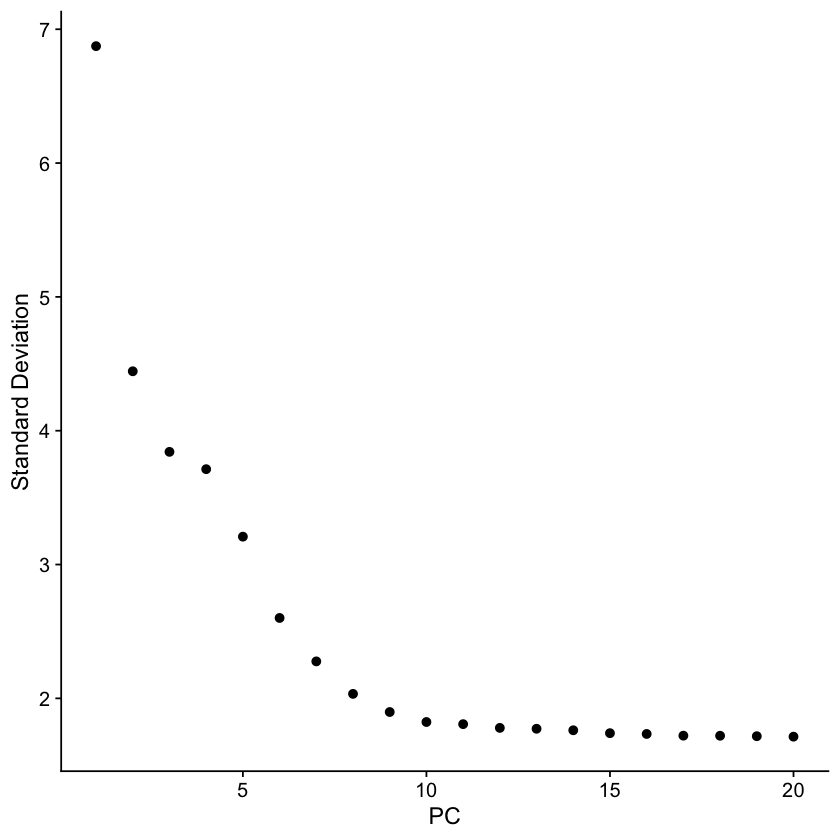

In [12]:
# Create an elbow plot
ElbowPlot(PBMC)

## Interpretation

The standard deviation decreases rapidly across the first several principal components before beginning to level off. This suggests that the first several PCs capture the strongest sources of variation in the dataset.

The practical analysis subsequently used the first 8 PCs for clustering and dimensionality reduction.

## 3. Graph-based Clustering and UMAP

I used the Louvain algorithm to identify groups of cells with similar gene-expression profiles.

A shared nearest-neighbour graph was constructed from the PCA representation before clustering.
I then used UMAP to visualise the resulting clusters in two dimensions.

In [13]:
# Find clusters using the Louvain algorithm
PBMC <- FindNeighbors(PBMC,
dims = 1:10) 

PBMC_05 <- FindClusters(PBMC,
resolution = 0.5,
random.seed = 42) 


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2700
Number of edges: 97892

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8720
Number of communities: 9
Elapsed time: 0 seconds


11:15:49 UMAP embedding parameters a = 0.9922 b = 1.112

11:15:49 Read 2700 rows and found 10 numeric columns

11:15:49 Using Annoy for neighbor search, n_neighbors = 30

11:15:49 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:15:50 Writing NN index file to temp file /var/folders/lq/694hg1hd6bj2r9c9hbs9r4740000gn/T//RtmpgwJs9x/file14de624f4550f

11:15:50 Searching Annoy index using 1 thread, search_k = 3000

11:15:50 Annoy recall = 100%

11:15:51 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:15:51 Initializing from normalized Laplacian + noise (using RSpectra)

11:15:51 Commencing optimization for 500 epochs, with 107868 positive edges

11:15:51 Using rng type: pcg

11:15:55 Optimization finished



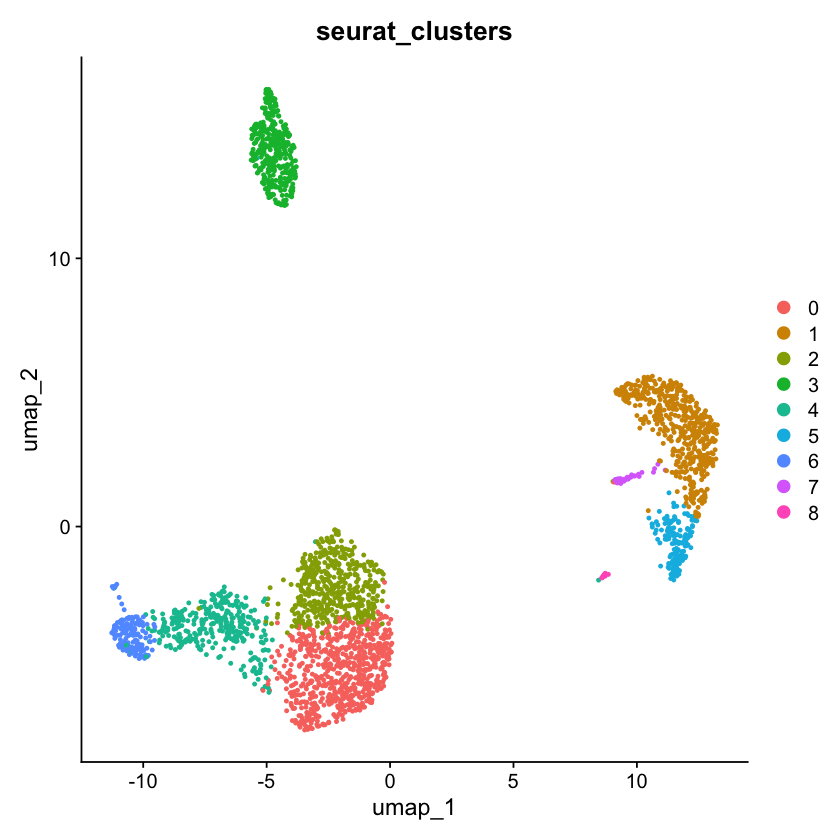

In [14]:
#visualize clusters using a UMAP representation:
# Run UMAP
PBMC_05 <- RunUMAP(PBMC_05,
dims = 1:10,
seed.use = 42) 

# Plot UMAP
DimPlot(PBMC_05, group.by = "seurat_clusters")

## Results

At a clustering resolution of 0.5, the analysis identified 8 clusters.

The UMAP representation allows cells with similar transcriptional profiles to be visualised as neighbouring groups.

## 4. Cluster Marker Analysis

To investigate the biological identity of the clusters, I identified genes that were differentially expressed between individual clusters.

In [15]:
# Find all markers of cluster 1
cluster1_markers <- FindMarkers(PBMC_05, ident.1 = 1)
head(cluster1_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
S100A8,0.000000e+00,6.592711,0.967,0.121,0.000000e+00
LGALS2,0.000000e+00,5.399831,0.900,0.059,0.000000e+00
FCN1,0.000000e+00,4.122462,0.953,0.147,0.000000e+00
S100A9,0.000000e+00,6.085371,0.994,0.215,0.000000e+00
CD14,4.401366e-294,5.795209,0.660,0.029,6.036033e-290
TYROBP,6.566321e-291,3.276352,0.994,0.264,9.005052e-287


## Cluster interpretation

Cluster 1 showed expression of genes associated with monocytes, including:

S100A8 and S100A9 → These are classic markers of inflammatory monocytes.

CD14 → A well-known monocyte surface marker.

FCN1 → Expressed in classical monocytes.

TYROBP → Associated with monocyte and macrophage activation.

LGALS2 → Also found in monocytes/macrophages, involved in immune regulation.

The presence of CD14, S100A8, S100A9 and FCN1 is consistent with a classical/inflammatory monocyte population (CD14⁺ monocytes) in the PBMC dataset.

This demonstrates how marker-gene expression can be used to move from computationally defined clusters towards biological cell-type interpretation.


## 5. Effect of Clustering Resolution

I repeated the clustering analysis using a higher resolution of 1.8 to investigate how the clustering structure changed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2700
Number of edges: 97892

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7262
Number of communities: 15
Elapsed time: 0 seconds


11:24:07 UMAP embedding parameters a = 0.9922 b = 1.112

11:24:07 Read 2700 rows and found 10 numeric columns

11:24:07 Using Annoy for neighbor search, n_neighbors = 30

11:24:07 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:24:08 Writing NN index file to temp file /var/folders/lq/694hg1hd6bj2r9c9hbs9r4740000gn/T//RtmpgwJs9x/file14de6467c4418

11:24:08 Searching Annoy index using 1 thread, search_k = 3000

11:24:08 Annoy recall = 100%

11:24:09 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:24:09 Initializing from normalized Laplacian + noise (using RSpectra)

11:24:09 Commencing optimization for 500 epochs, with 107868 positive edges

11:24:09 Using rng type: pcg

11:24:13 Optimization finished



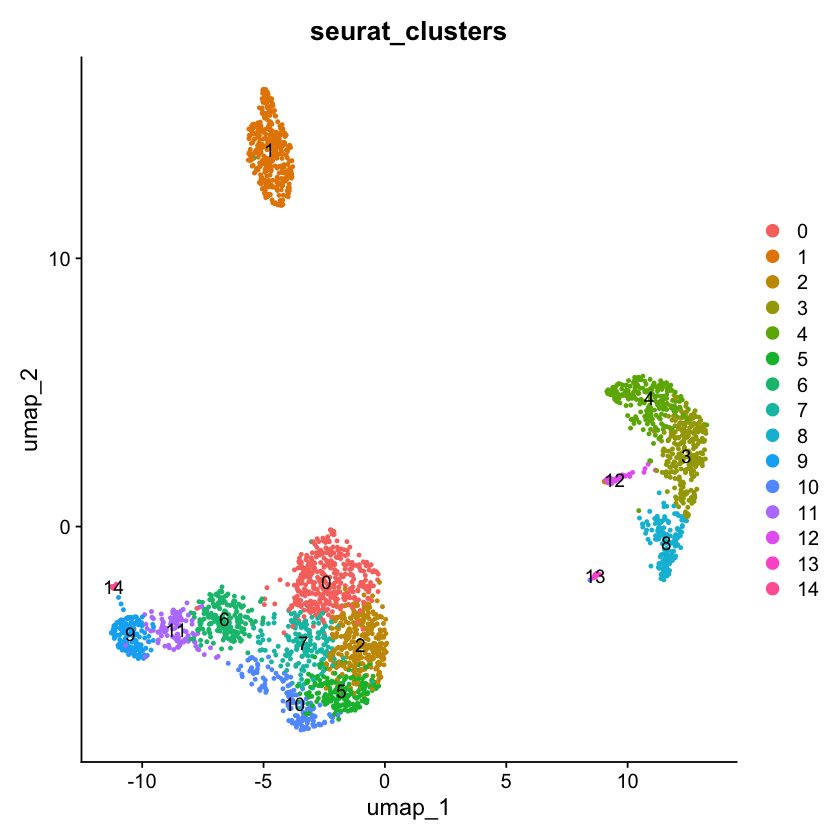

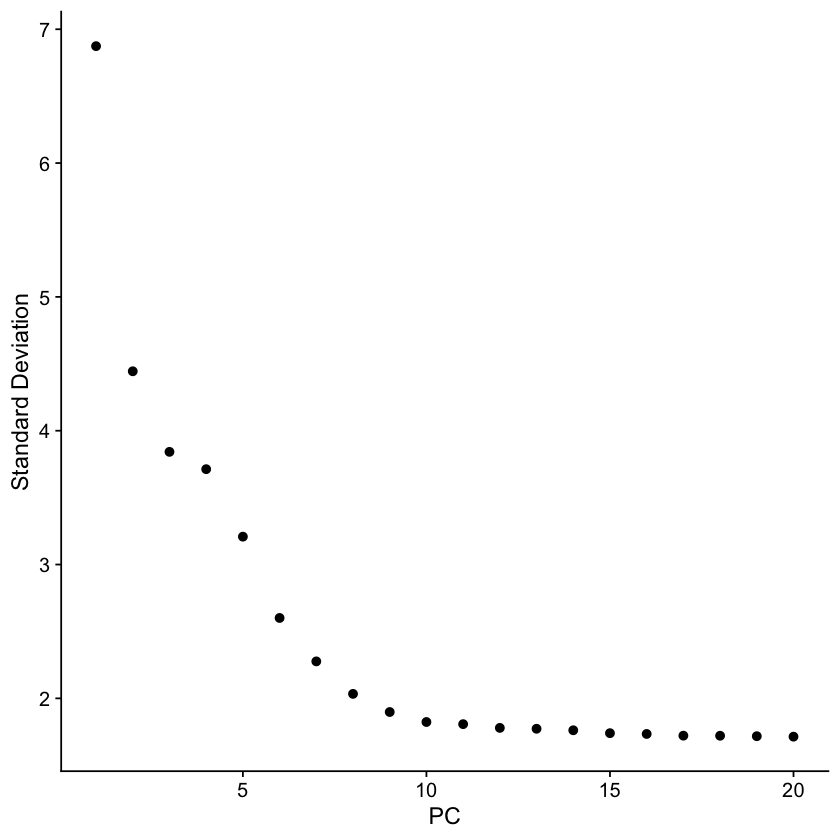

In [ ]:
# Construct the nearest-neighbour graph using the Louvain algorithm
PBMC <- FindNeighbors(
  PBMC,
  dims = 1:10
)

# Cluster at higher resolution
PBMC_1.8 <- FindClusters(
  PBMC,
  resolution = 1.8,
  random.seed = 42
)

# Visualise the higher-resolution clustering
PBMC_1.8 <- RunUMAP(
  PBMC_1.8,
  dims = 1:10,
  seed.use = 42
)

# Plot UMAP
DimPlot(
  PBMC_1.8,
  group.by = "seurat_clusters",
  label = TRUE
)
# Create an elbow plot
ElbowPlot(PBMC)


In [19]:
# Find all markers of cluster 7
cluster7_markers <- FindMarkers(PBMC_1.8, ident.1 = 7)
head(cluster7_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RPS3,9.535135e-28,0.4369154,1.000,0.994,1.307648e-23
IL32,1.032163e-27,1.0563704,0.927,0.528,1.415508e-23
HLA-DRA,1.080349e-24,-4.3823798,0.236,0.579,1.481590e-20
CD3D,2.002726e-23,0.9598136,0.899,0.494,2.746538e-19
HLA-DRB1,2.421878e-21,-3.4678866,0.129,0.481,3.321364e-17
LDHB,8.015928e-20,0.9179387,0.888,0.655,1.099304e-15


### Interpretation
Increasing the resolution to 1.8 produced a larger number of smaller clusters. This can reveal subpopulations that were previously grouped together at lower resolution.

Cluster 7 showed expression of **CD3D** and **IL32**, supporting a T-cell identity. CD3D is a core component of the T-cell receptor complex, while IL32 is commonly expressed in T and NK cells.

The expression of **HLA-DRA** and **HLA-DRB1** suggests increased MHC class II activity. Together, these markers are consistent with an **activated T-cell population**, although marker-based annotation alone cannot definitively distinguish the precise T-cell subtype.

This demonstrates an important consideration in single-cell analysis: clustering resolution can influence how cellular heterogeneity is represented and interpreted.


## 6. UMAP vs t-SNE

As an additional analysis, I generated a t-SNE representation of the cells.

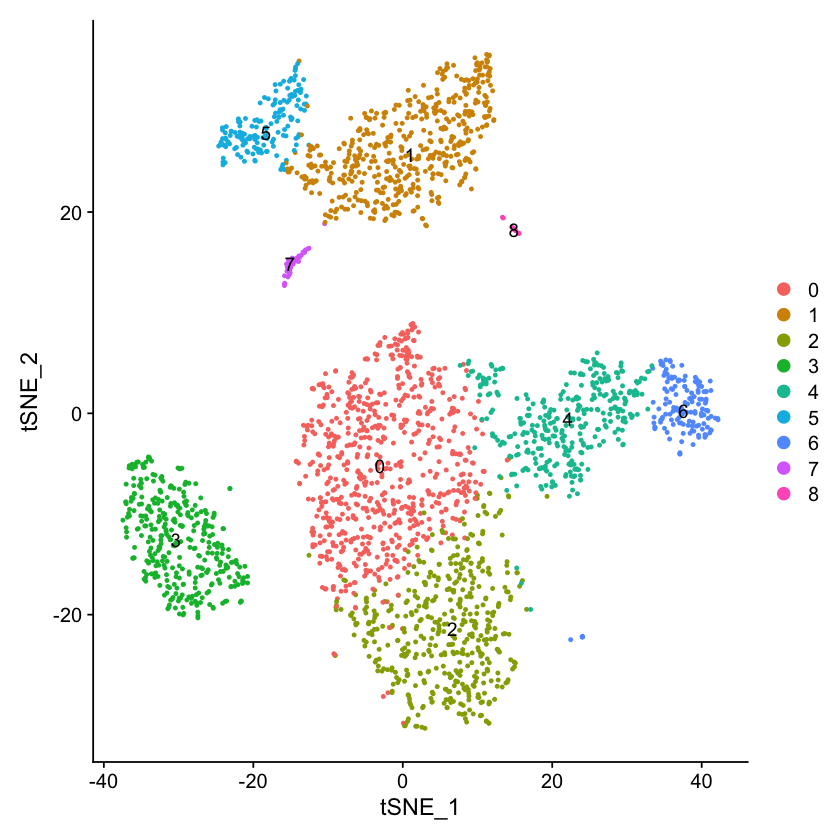

In [20]:
# Run t-SNE
PBMC_05 <- RunTSNE(PBMC_05, dims = 1:10)

# Plot t-SNE clusters
DimPlot(PBMC_05, reduction = "tsne", label = TRUE)


## Comparison

The UMAP and t-SNE representations produce similar broad cluster structures but emphasise different aspects of the data.

UMAP preserves local neighbourhood relationships while also attempting to retain aspects of the global structure. t-SNE places greater emphasis on local neighbourhood structure, often producing visually well-separated clusters.

## Conclusion

This project applied a standard single-cell RNA-seq analysis workflow to PBMC gene-expression data using Seurat.

The analysis progressed from raw count-matrix inspection through preprocessing, PCA, graph-based clustering and dimensionality reduction. Marker-gene analysis was then used to investigate the biological identities of individual clusters.

Changing the clustering resolution demonstrated how computational parameters can affect the detection of cellular subpopulations, while comparison of UMAP and t-SNE highlighted differences between dimensionality-reduction approaches.

Overall, the project demonstrates how computational methods can be combined with biological knowledge to analyse and interpret single-cell transcriptomic data.

### Key Skills Demonstrated
- R programming
- Seurat
- Single-cell RNA-seq analysis
- Gene-expression data processing
- Principal component analysis
- Graph-based clustering
- Louvain community detection
- UMAP
- t-SNE
- Differential gene-expression analysis
- Cell-type identification using marker genes
- Biological interpretation of computational results

### Academic Context

This project was completed as part of Computational Biology coursework at Cornell University.

The repository presents my implementation, analysis and interpretation as part of my personal computational biology portfolio. ## Academic Context

### Data Availability

The PBMC count matrix used in this analysis was provided as part of the course practical and is not included in this repository. The analysis code and results are presented to demonstrate the computational workflow and biological interpretation.